In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
s = "https://archive.ics.uci.edu/ml/"\
    "machine-learning-databases/iris/iris.data"

df = pd.read_csv(
    s,
    header=None,
    encoding="utf-8"
)

In [3]:
df.tail()

,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [4]:
y = df.iloc[0:100, 4].values
y = np.where(y == "Iris-setosa", 0, 1)
y_train, y_final = y[:75], y[75:]

X = df.iloc[0:100, [0, 2]].values
X_train, X_final = X[:75], X[75:]

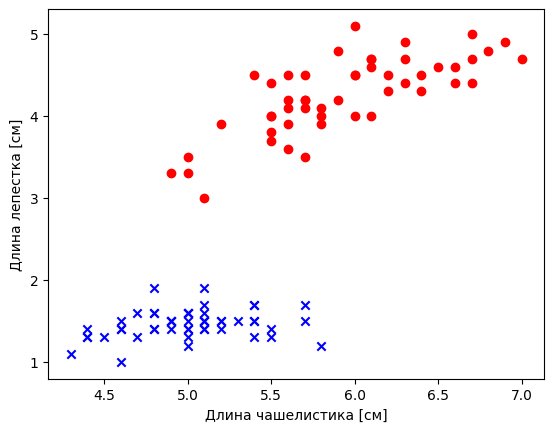

In [5]:
plt.scatter(
    X[:50, 0],
    X[:50, 1],
    color="blue",
    marker="x",
    label="Setosa",
)

plt.scatter(
    X[50:100, 0],
    X[50:100, 1],
    color="red",
    marker="o",
    label="Versicolor",
)

plt.xlabel("Длина чашелистика [см]")
plt.ylabel("Длина лепестка [см]")

plt.show()

In [23]:
def porog_func():
    pass


class Perceptron:
    """
    Перцептронный классификатор.

    Параметры:
    eta: float
    - скорость обучения перцептнора.

    n_iter: int
    - кол-во эпох для обучения.

    random_state: int
    - опорное значения для генератора случайных чисел.

    Атрибуты:
    w_: 1d-array
    - веса после подгонки.

    b_: Scalar
    - смещение после подгонки.

    errors_: list
    - кол-во неправильных классификаций в каждой эпохе.
    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """
        Соответствие тренировочным данным.

        Параметры:
        X: {array-like}, shape = [n_examples, n_features]
        - обучающий вектор, где n_examples - кол-во образцов,
          a n_features - кол-во признаков.

        y: {array-like}, shape = [n_examples]
        - целевые значения.
        """
        rgen = np.random.RandomState(self.random_state)

        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        # self.w_ = np.zeros(X.shape[1])

        self.b_ = np.float64(0.)
        
        self.errors_ = []

        for _ in range(self.n_iter):
            errors = 0

            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w_ += update * xi # xi - мультипликаторный коэфф.
                self.b_ += update
                errors += int(update != 0.)
            
            self.errors_.append(errors)
        
        return self

    def net_input(self, X):
        """
        Вычисление фактического ввода.
        """
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        """
        Возврат метки класса после шага.
        """
        return np.where(self.net_input(X) >= 0., 1, 0)

In [24]:
ppn = Perceptron(
    eta=0.9,
    n_iter=25,
    random_state=1,
)

ppn.fit(X_train, y_train)

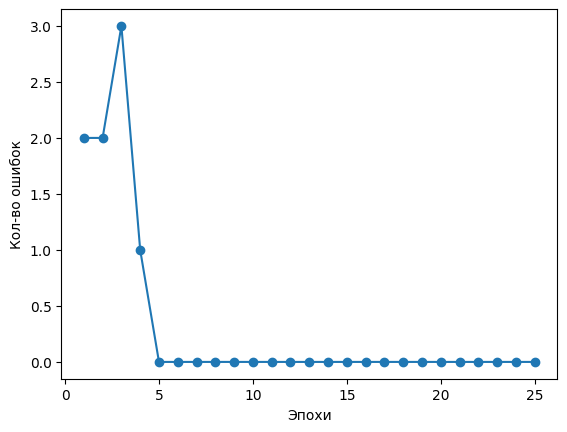

In [25]:
plt.plot(
    range(1, len(ppn.errors_) + 1),
    ppn.errors_,
    marker="o",
)

plt.xlabel("Эпохи")
plt.ylabel("Кол-во ошибок")
plt.show()

In [26]:
print("Финальная проверка")


errors_final = 0

for xi, target in zip(X_final, y_final):
    result = target - ppn.predict(xi)

    errors_final += int(result != 0.)

print(errors_final)

Финальная проверка
2


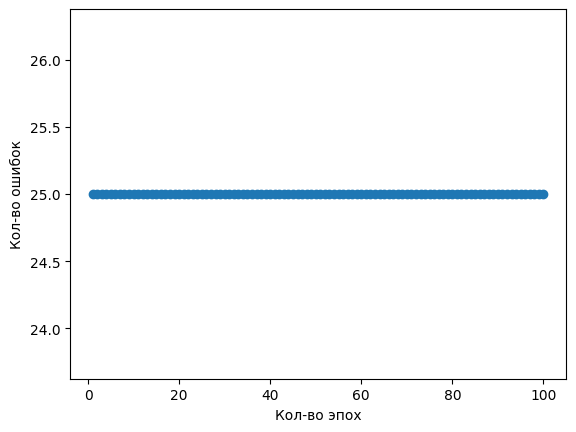

In [29]:
check_errors = []

for epoch in range(1, 100 + 1):
    new_ppn = Perceptron(n_iter=epoch)

    new_ppn.fit(X_train, y_train)

    errors = sum((target - new_ppn.predict(xi) != 0.) for xi, target in zip(X_final, y_train))

    check_errors.append(errors)


plt.plot(range(1, 100 + 1), check_errors, marker="o")
plt.xlabel("Кол-во эпох")
plt.ylabel("Кол-во ошибок")
plt.show()

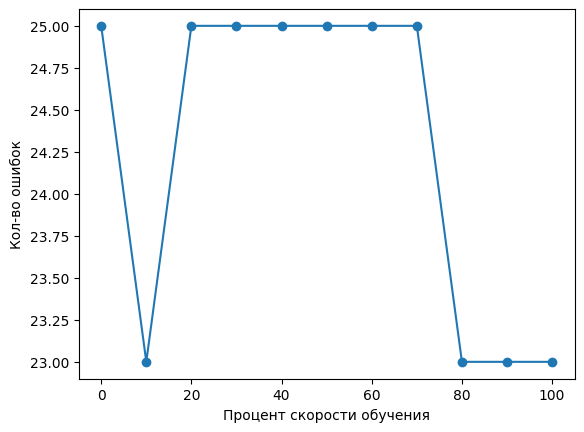

In [30]:
check_errors = []

for pr_eta in range(0, 100 + 1, 10):
    eta = pr_eta / 100
    new_ppn = Perceptron(eta=eta)

    new_ppn.fit(X_train, y_train)

    errors = sum(
        (target - new_ppn.predict(xi) != 0.0)
        for xi, target in zip(X_final, y_train)
    )

    check_errors.append(errors)


plt.plot(range(0, 100 + 1, 10), check_errors, marker="o")
plt.xlabel("Процент скорости обучения")
plt.ylabel("Кол-во ошибок")
plt.show()